In [1]:
library(WGCNA)
library(clusterProfiler)
library(ggplot2)

Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust





Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor


clusterProfiler v4.18.2 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter




In [2]:
setwd("/home/seba/github_repos/crc_weighted_network/taiwanese_cohort")

In [4]:
# Intra module preservation on white cohort
datExpr_tumor <- readRDS("rna_tumor/datExpr_clean.rds")
datExpr_normal <- readRDS("rna_normal/datExpr_clean.rds")

In [5]:
commonGenes <- intersect(colnames(datExpr_tumor), colnames(datExpr_normal))

datExpr_tumor  <- datExpr_tumor[, commonGenes, drop=FALSE]
datExpr_normal <- datExpr_normal[, commonGenes, drop=FALSE]

In [6]:
gene2mod <- read.table("rna_tumor/module_membership_gene2module.tsv", header=TRUE, sep="\t", stringsAsFactors=FALSE)
refColors_map <- setNames(gene2mod$module, gene2mod$gene)
refColors <- refColors_map[commonGenes]

In [7]:
multiExpr <- list(
  Ref  = list(data = datExpr_tumor),
  Test = list(data = datExpr_normal)
)

colorList <- list(Ref = refColors)

In [8]:
# Do this only if intra_module_preservation_white_tumor_vs_normal.rds does not exist
if (!file.exists("intra_module_preservation_white_tumor_vs_normal.rds")){
    mp <- modulePreservation(
    multiExpr, colorList,
    referenceNetworks = 1,
    networkType = "signed",
    corFnc = "bicor",     # or "cor" if Pearson
    nPermutations = 200,
    randomSeed = 1,
    verbose = 3
)
saveRDS(mp, file="intra_module_preservation_white_tumor_vs_normal.rds")
} else {
    mp <- readRDS("intra_module_preservation_white_tumor_vs_normal.rds")
}

  ..checking data for excessive amounts of missing data..
     Flagging genes and samples with too many missing values...
      ..step 1
     Flagging genes and samples with too many missing values...
      ..step 1
  ..unassigned 'module' name: grey 
  ..all network sample 'module' name: gold
  ..calculating observed preservation values
  ..calculating permutation Z scores
 ..Working with set 1 as reference set
 ....working with set 2 as test set
  ......working on permutation 1
  ......working on permutation 2
  ......working on permutation 3
  ......working on permutation 4
  ......working on permutation 5
  ......working on permutation 6
  ......working on permutation 7
  ......working on permutation 8
  ......working on permutation 9
  ......working on permutation 10
  ......working on permutation 11
  ......working on permutation 12
  ......working on permutation 13
  ......working on permutation 14
  ......working on permutation 15
  ......working on permutation 16
  ......worki

In [9]:
Ztab  <- mp$preservation$Z$ref.Ref$inColumnsAlsoPresentIn.Test
Ztab <- as.data.frame(Ztab)

In [10]:
out <- data.frame(
  module = rownames(Ztab),
  size = Ztab$moduleSize,
  Zsummary_pres = Ztab$Zsummary.pres,
  Zdensity_pres = Ztab$Zdensity.pres,
  Zconnectivity_pres = Ztab$Zconnectivity.pres,
  stringsAsFactors = FALSE
)

out <- out[order(-out$Zsummary_pres), ]
head(out, 20)

,module,size,Zsummary_pres,Zdensity_pres,Zconnectivity_pres
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,blue,1000,69.243411,117.361583,21.125240
37,salmon,337,30.509529,43.337643,17.681415
26,mediumpurple3,86,27.079533,48.776130,5.382936
12,darkturquoise,188,26.444779,41.224514,11.665044
3,brown,958,26.158710,13.456020,38.861399
15,green,605,21.087615,31.478328,10.696901
42,tan,380,18.215295,27.224794,9.205797
31,pink,536,17.269226,23.610635,10.927816
43,turquoise,1000,16.434811,12.033223,20.836399


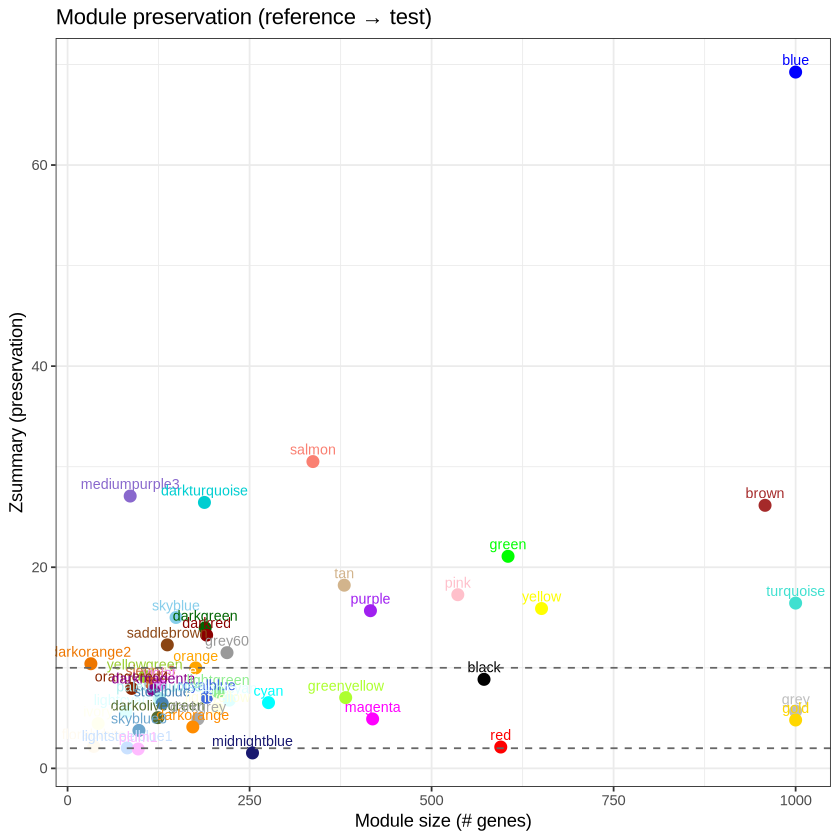

In [11]:
ggplot(out, aes(x = size, y = Zsummary_pres, color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_hline(yintercept = c(2, 10),
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Module size (# genes)",
    y = "Zsummary (preservation)",
    title = "Module preservation (reference → test)"
  ) +
  theme_bw()

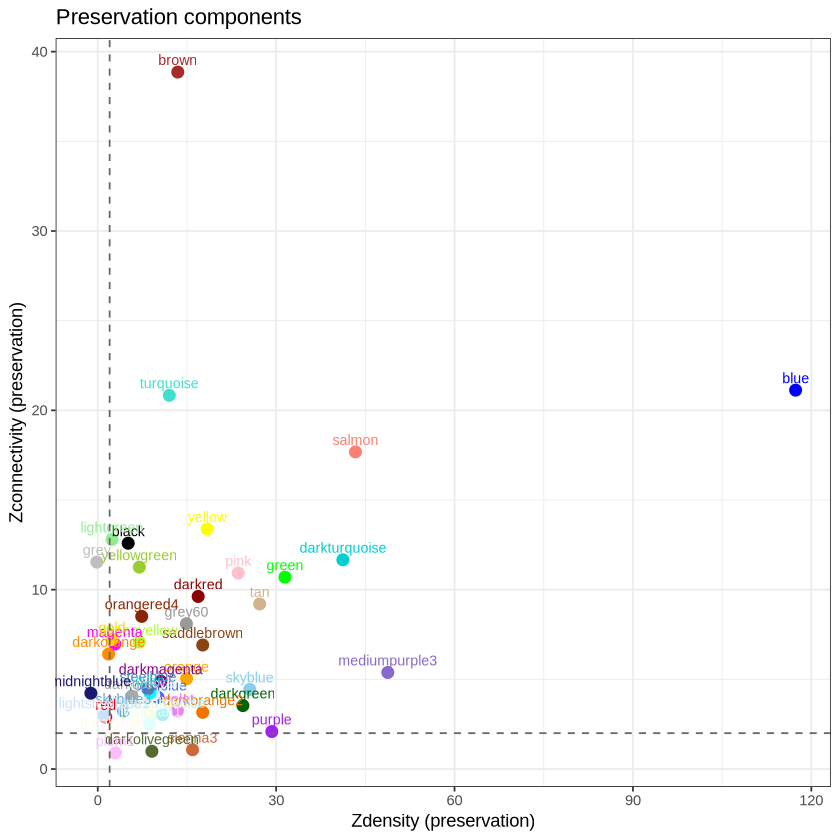

In [12]:
ggplot(out, aes(x = Zdensity_pres, y = Zconnectivity_pres,
                color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_vline(xintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  geom_hline(yintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Zdensity (preservation)",
    y = "Zconnectivity (preservation)",
    title = "Preservation components"
  ) +
  theme_bw()


In [13]:
gene2mod_normal <- read.table("rna_tumor/module_membership_gene2module.tsv", header=TRUE, sep="\t", stringsAsFactors=FALSE)
refColors_map <- setNames(gene2mod_normal$module, gene2mod_normal$gene)
refColors <- refColors_map[commonGenes]

In [14]:
multiExpr <- list(
  Ref= list(data = datExpr_normal),
  Test  = list(data = datExpr_tumor)
)

colorList <- list(Ref = refColors)

In [15]:
# Do this only if intra_module_preservation_white_normal_vs_tumor.rds does not exist
if (!file.exists("intra_module_preservation_white_normal_vs_tumor.rds")){
    mp <- modulePreservation(
    multiExpr, colorList,
    referenceNetworks = 1,
    networkType = "signed",
    corFnc = "bicor",     # or "cor" if Pearson
    nPermutations = 200,
    randomSeed = 1,
    verbose = 3
)
saveRDS(mp, file="intra_module_preservation_white_normal_vs_tumor.rds")
} else {
    mp <- readRDS("intra_module_preservation_white_normal_vs_tumor.rds")
}

  ..checking data for excessive amounts of missing data..
     Flagging genes and samples with too many missing values...
      ..step 1
     Flagging genes and samples with too many missing values...
      ..step 1
  ..unassigned 'module' name: grey 
  ..all network sample 'module' name: gold
  ..calculating observed preservation values
  ..calculating permutation Z scores
 ..Working with set 1 as reference set
 ....working with set 2 as test set
  ......working on permutation 1
  ......working on permutation 2
  ......working on permutation 3
  ......working on permutation 4
  ......working on permutation 5
  ......working on permutation 6
  ......working on permutation 7
  ......working on permutation 8
  ......working on permutation 9
  ......working on permutation 10
  ......working on permutation 11
  ......working on permutation 12
  ......working on permutation 13
  ......working on permutation 14
  ......working on permutation 15
  ......working on permutation 16
  ......worki

In [16]:
Ztab  <- mp$preservation$Z$ref.Ref$inColumnsAlsoPresentIn.Test
Ztab <- as.data.frame(Ztab)

In [17]:
out <- data.frame(
  module = rownames(Ztab),
  size = Ztab$moduleSize,
  Zsummary_pres = Ztab$Zsummary.pres,
  Zdensity_pres = Ztab$Zdensity.pres,
  Zconnectivity_pres = Ztab$Zconnectivity.pres,
  stringsAsFactors = FALSE
)

out <- out[order(-out$Zsummary_pres), ]
head(out, 20)

,module,size,Zsummary_pres,Zdensity_pres,Zconnectivity_pres
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,blue,1000,139.36296,261.23550,17.490414
3,brown,958,126.22379,220.49353,31.954046
37,salmon,337,87.21654,150.57007,23.863004
43,turquoise,1000,80.00321,134.90717,25.099255
31,pink,536,63.55169,115.74993,11.353464
46,yellow,651,52.85160,93.11881,12.584388
34,red,595,51.19026,99.83257,2.547945
47,yellowgreen,106,48.84004,85.91192,11.768151
15,green,605,46.95469,84.02156,9.887821


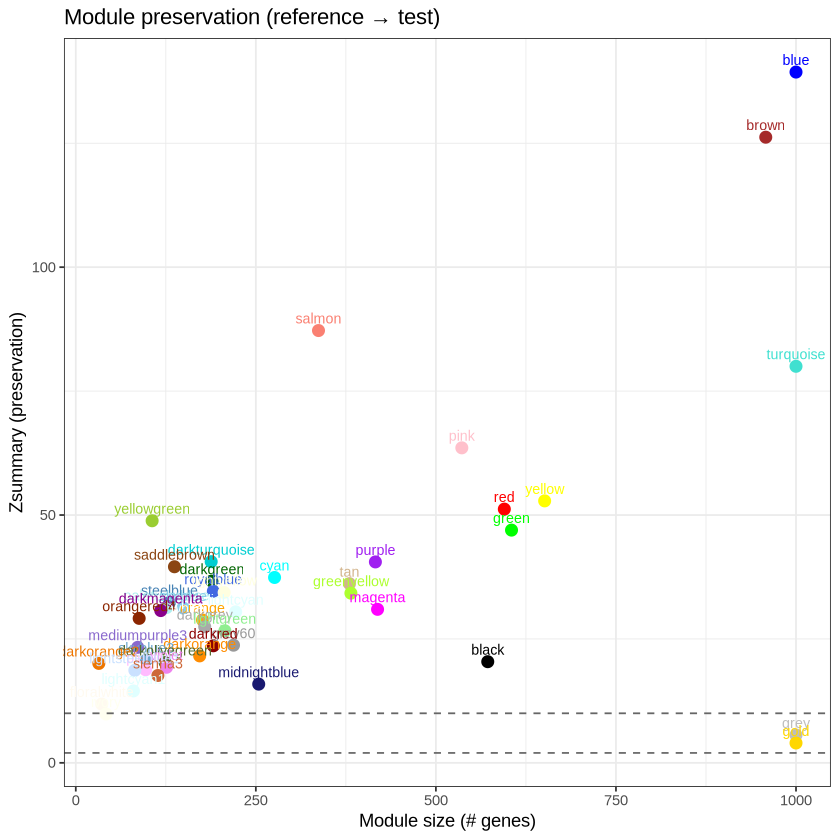

In [18]:
ggplot(out, aes(x = size, y = Zsummary_pres, color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_hline(yintercept = c(2, 10),
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Module size (# genes)",
    y = "Zsummary (preservation)",
    title = "Module preservation (reference → test)"
  ) +
  theme_bw()

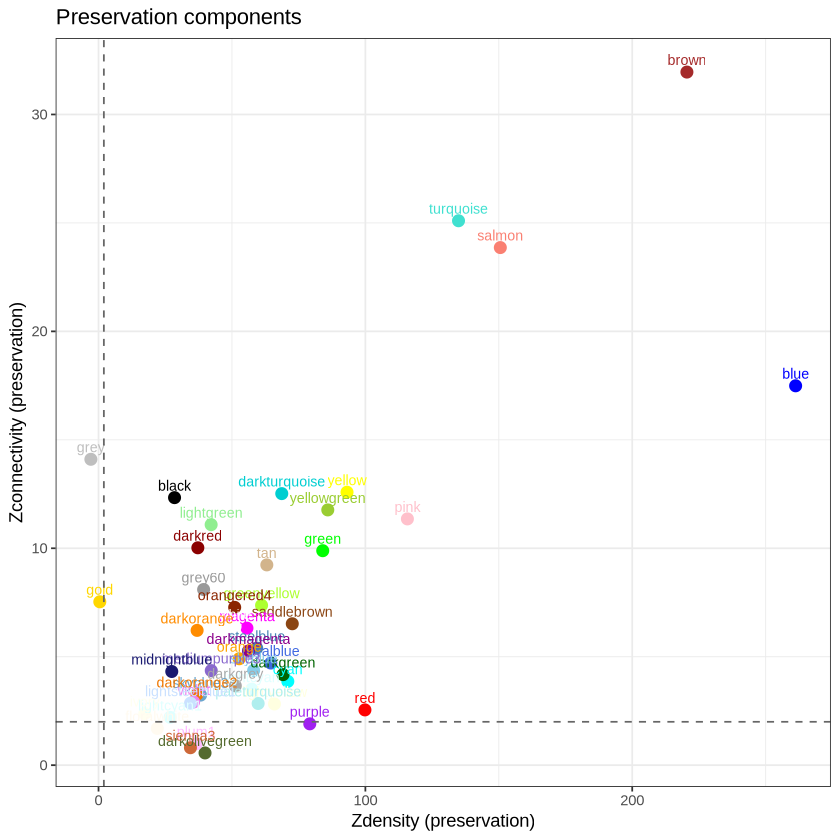

In [19]:
ggplot(out, aes(x = Zdensity_pres, y = Zconnectivity_pres,
                color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_vline(xintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  geom_hline(yintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Zdensity (preservation)",
    y = "Zconnectivity (preservation)",
    title = "Preservation components"
  ) +
  theme_bw()
